# AR Model Notebook

This notebook covers:
1. **Setup** - Imports and helper functions
2. **Simulation** - Generating synthetic hierarchical AR(1) data and checking stationarity
3. **Model 1: AR(1) on Synthetic Data** - Fitting `ar_1.stan` to simulated data
4. **Model 2: Hierarchical AR (ICAR Prior) on Synthetic Data** - Fitting `ar_1_hierarchical.stan`
5. **Model 3: AR(1) on CTA Red Line Data** - Fitting `ar_1_cta.stan` to real weekly ridership

---
## 1. Setup

Imports and CmdStan path configuration.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from cmdstanpy import CmdStanModel, set_cmdstan_path
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

In [5]:
def sim_ar_model(alpha, beta, sigma, T, initial=0, seed=None):
    """Simulate an AR(1) process.

    Parameters
    ----------
    alpha : float
        Intercept.
    beta : float
        Lag-1 coefficient.
    sigma : float
        Innovation standard deviation.
    T : int
        Number of time steps to simulate.
    initial : float
        Initial value for Y[0].
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    Y : array of shape (T,)
        Simulated time series.
    """
    np.random.seed(seed)
    assert T >= 1

    Y = np.zeros(T)
    epsilon = np.random.normal(0, sigma, size=T)

    Y[0] = initial

    for t in range(1, T):
        Y[t] = alpha + beta * Y[t - 1] + epsilon[t]
    return Y

## 2. Simulate AR(1) Data

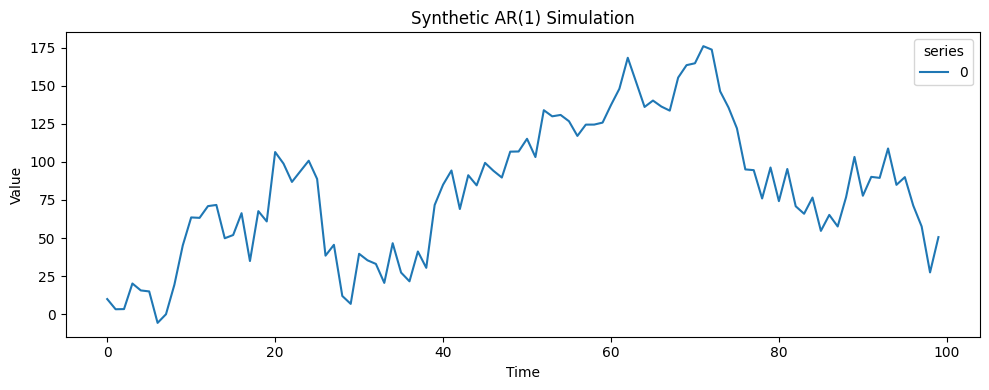

In [ ]:
T = 100
alpha = 1
beta= 0.98
sigma = 20

y = sim_ar_model(alpha = 1, beta = 0.98, initial = 10, sigma = 20, T = T)

df_sim = pd.DataFrame(y)
df_sim["t"] = range(T)
df_sim_long = df_sim.melt(id_vars="t", var_name="series", value_name="value")

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_sim_long, x="t", y="value", hue="series")
plt.title("Synthetic AR(1) Simulation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 3. Model 1: AR(1) on Simulated Data

In [ ]:
stan_data_ar1_sim = {
    "T": T,
    "Y": y
}

ar_mod = CmdStanModel(stan_file="ar_1.stan")
ar_mod_post = ar_mod.sample(data=stan_data_ar1_sim)
print(ar_mod_post.diagnose())

### 3.1 Parameter Recovery

In [ ]:
ar_mod_params = ar_mod_post.stan_variables()

print("True alpha:", alpha)
print("Estimated alpha:", ar_mod_params["alpha"].mean(axis=0))
print()
print("True beta")
print("Estimated beta:", ar_mod_params["beta"].mean(axis=0))
print()
print("True sigma:")
print("Estimated sigma:", ar_mod_params["sigma"].mean(axis=0))

In [ ]:
print(ar_mod_post.summary())

## 4. Simulate Network AR(1) Data

In [ ]:
def sim_ar_net_model(c, beta, W, tau, alpha, T, initial=None, seed=None):
    """Simulate a network AR(1) with CAR-structured innovations.

    Model:
        Y_i(t) = c_i + beta_i * Y_i(t-1) + epsilon(t)
        epsilon(t) ~ MVN(0, Sigma)
        Sigma = (tau * (D - rho * W))^{-1}     [proper CAR]

    Parameters
    ----------
    c : array of shape (K,)
        Node-specific intercepts.
    beta : array of shape (K,)
        Node-specific AR(1) coefficients.
    W : array of shape (K, K)
        Adjacency matrix (symmetric, zero diagonal).
    tau : float
    alpha : float (0 < alpha < 1)
        Controls the amount of spatial correlation
    T : int
        Number of time periods
    initial : array of shape (K,) or None
    seed : int or None

    Returns
    -------
    Y : array of shape (T, K)
        Simulated multivariate time series.
    Sigma : array of shape (K, K)
        Innovation covariance matrix used.
    """

    np.random.seed(seed)
    K = len(c)
    assert W.shape == (K, K)
    assert T >= 1

    # Build precision matrix (Q)
    D = np.diag(W.sum(axis=1))
    Q = tau * (D - alpha * W)
    Sigma = np.linalg.inv(Q)

    # Simulate
    Y = np.zeros((T, K))
    if initial is not None:
        Y[0] = initial

    epsilon = np.random.multivariate_normal(np.zeros(K), Sigma, size=T)

    for t in range(1, T):
        Y[t] = c + beta * Y[t - 1] + epsilon[t]

    return Y, Sigma

In [38]:
# 5-node linear chain: 1--2--3--4--5
K = 5
W = np.zeros((K, K))
for i in range(K - 1):
    W[i, i + 1] = 1
    W[i + 1, i] = 1

print("Adjacency matrix W:")
print(W)

# Simulation parameters
c_net = np.array([1.0, 1.5, 2.0, 1.5, 1.0])       # node intercepts
beta_net = np.array([0.8, 0.85, 0.9, 0.85, 0.8])   # node AR coefficients
alpha_net = 0.8   # spatial correlation (0 < alpha < 1)
tau_net = 1.0     # precision scale
T_net = 200

Y_net, Sigma_net = sim_ar_net_model(
    c=c_net, beta=beta_net, W=W,
    tau=tau_net, alpha=alpha_net, T=T_net, seed=42
)

print(f"\nSimulated data shape: {Y_net.shape}")
print(f"\nInnovation covariance Sigma:")
print(np.round(Sigma_net, 3))

Adjacency matrix W:
[[0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]

Simulated data shape: (200, 5)

Innovation covariance Sigma:
[[1.68  0.85  0.444 0.261 0.209]
 [0.85  1.062 0.556 0.327 0.261]
 [0.444 0.556 0.944 0.556 0.444]
 [0.261 0.327 0.556 1.062 0.85 ]
 [0.209 0.261 0.444 0.85  1.68 ]]
